In [ ]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import nltk
nltk.download('stopwords')  # If using stopwords
nltk.download('punkt')      # If using tokenization
nltk.download('wordnet')    # If using lemmatization

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

**Importing The Libraries**

In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')
from textblob import TextBlob
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

**Loading The Dataset**

In [3]:
df = pd.read_csv('vaccination_tweets.csv')

In [4]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,False
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,NaN,Twitter Web App,1,1,False
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",NaN,Twitter Web App,446,2129,False
4,1337854064604966912,Citizen News Channel,NaN,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,False


**Data Cleaning**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11020 entries, 0 to 11019
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                11020 non-null  int64 
 1   user_name         11020 non-null  object
 2   user_location     8750 non-null   object
 3   user_description  10340 non-null  object
 4   user_created      11020 non-null  object
 5   user_followers    11020 non-null  int64 
 6   user_friends      11020 non-null  int64 
 7   user_favourites   11020 non-null  int64 
 8   user_verified     11020 non-null  bool  
 9   date              11020 non-null  object
 10  text              11020 non-null  object
 11  hashtags          8438 non-null   object
 12  source            11019 non-null  object
 13  retweets          11020 non-null  int64 
 14  favorites         11020 non-null  int64 
 15  is_retweet        11020 non-null  bool  
dtypes: bool(2), int64(6), object(8)
memory usage: 1.2+ MB


In [6]:
df.describe()

,id,user_followers,user_friends,user_favourites,retweets,favorites
count,1.102000e+04,1.102000e+04,11020.000000,1.102000e+04,11020.000000,11020.000000
mean,1.372977e+18,3.518827e+04,1170.470236,1.533289e+04,1.360436,7.510617
std,3.311622e+16,2.942509e+05,2798.429673,4.944401e+04,11.364732,51.192608
min,1.337728e+18,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,1.347623e+18,1.110000e+02,164.000000,4.360000e+02,0.000000,0.000000
50%,1.360274e+18,4.790000e+02,460.000000,2.323500e+03,0.000000,1.000000
75%,1.395234e+18,2.171250e+03,1221.000000,1.114075e+04,1.000000,4.000000
max,1.463244e+18,1.371493e+07,103226.000000,1.213794e+06,678.000000,2315.000000


In [7]:
df.isnull().sum()

id                     0
user_name              0
user_location       2270
user_description     680
user_created           0
user_followers         0
user_friends           0
user_favourites        0
user_verified          0
date                   0
text                   0
hashtags            2582
source                 1
retweets               0
favorites              0
is_retweet             0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11020 entries, 0 to 11019
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                11020 non-null  int64 
 1   user_name         11020 non-null  object
 2   user_location     8750 non-null   object
 3   user_description  10340 non-null  object
 4   user_created      11020 non-null  object
 5   user_followers    11020 non-null  int64 
 6   user_friends      11020 non-null  int64 
 7   user_favourites   11020 non-null  int64 
 8   user_verified     11020 non-null  bool  
 9   date              11020 non-null  object
 10  text              11020 non-null  object
 11  hashtags          8438 non-null   object
 12  source            11019 non-null  object
 13  retweets          11020 non-null  int64 
 14  favorites         11020 non-null  int64 
 15  is_retweet        11020 non-null  bool  
dtypes: bool(2), int64(6), object(8)
memory usage: 1.2+ MB


In [9]:
df = df.apply(lambda col: col.fillna(col.mean()) if col.dtype in ['int64', 'float64'] else col.fillna("Unknown"))

In [10]:
df.isnull().sum()

id                  0
user_name           0
user_location       0
user_description    0
user_created        0
user_followers      0
user_friends        0
user_favourites     0
user_verified       0
date                0
text                0
hashtags            0
source              0
retweets            0
favorites           0
is_retweet          0
dtype: int64

In [11]:
df.drop_duplicates()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,False
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,Unknown,Twitter Web App,1,1,False
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",Unknown,Twitter Web App,446,2129,False
4,1337854064604966912,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11015,1460932683630977025,theSun,Petaling Jaya,Breaking news updates from the website of Mala...,2009-07-29 01:58:44,151937,465,593,False,2021-11-17 11:27:49,"The number of Covid-19 cases today, 17 Novembe...",Unknown,Twitter Web App,2,6,False
11016,1460809350792896516,Sujan,Unknown,________________________ •Napricorn• •It's jus...,2013-01-28 11:48:20,4259,622,156941,False,2021-11-17 03:17:44,First dose ✅\n#PfizerBioNTech,['PfizerBioNTech'],Twitter for Android,0,4,False
11017,1460581918295031809,theSun,Petaling Jaya,Breaking news updates from the website of Mala...,2009-07-29 01:58:44,151937,465,593,False,2021-11-16 12:14:00,"The number of Covid-19 cases today, 16 Novembe...",Unknown,Twitter Web App,3,5,False
11018,1460344277951782922,Aleksejs Jackovs,Ireland,#Scientificresearcher in #InformationTechnolog...,2012-08-13 13:47:03,1,38,99,False,2021-11-15 20:29:42,#PfizerBioNTech has developed new pill #Paxlov...,"['PfizerBioNTech', 'Paxlovid', 'COVID19']",Twitter Web App,1,1,False


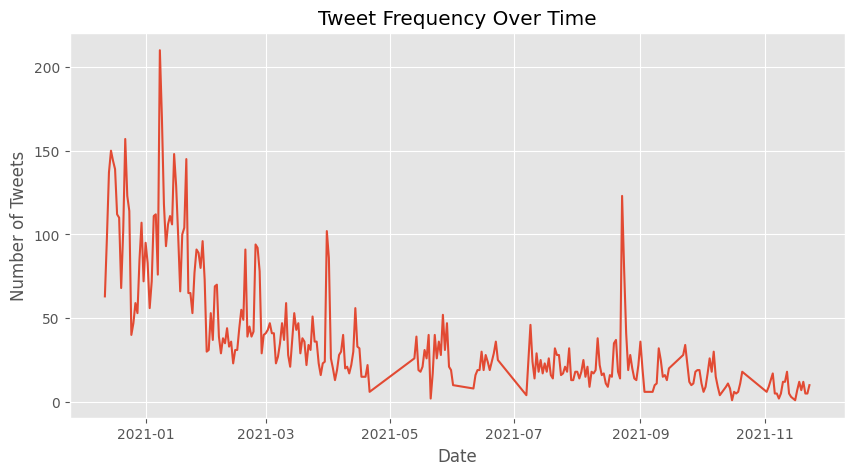

In [12]:
#Analyzing tweet trends over time.
df['date'] = pd.to_datetime(df['date'])
df['date'].dt.date.value_counts().sort_index().plot(kind='line', figsize=(10,5))
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.title("Tweet Frequency Over Time")
plt.show()

In [13]:
df.columns

Index(['id', 'user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'text', 'hashtags', 'source', 'retweets', 'favorites',
       'is_retweet'],
      dtype='object')

In [14]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,False
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,Unknown,Twitter Web App,1,1,False
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",Unknown,Twitter Web App,446,2129,False
4,1337854064604966912,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,False


**Feature Extraction**

In [15]:
df["follower_friend_ratio"] = df['user_followers']/(df['user_friends']+1)

In [16]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet,follower_friend_ratio
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,False,0.239220
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,Unknown,Twitter Web App,1,1,False,1.250375
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False,0.112360
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",Unknown,Twitter Web App,446,2129,False,12.497458
4,1337854064604966912,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,False,0.261618


In [17]:
#Total Engagement
df['total_engagement'] = df['retweets'] + df['favorites']

In [18]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet,follower_friend_ratio,total_engagement
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,False,0.239220,0
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,Unknown,Twitter Web App,1,1,False,1.250375,2
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,False,0.112360,0
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",Unknown,Twitter Web App,446,2129,False,12.497458,2575
4,1337854064604966912,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,False,0.261618,0


In [19]:
df["is_retweet"] = df["is_retweet"].astype(int)  # Convert boolean to 0/1

In [20]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet,follower_friend_ratio,total_engagement
0,1340539111971516416,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,405,1692,3247,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,0,0,0,0.239220,0
1,1338158543359250433,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,834,666,178,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,Unknown,Twitter Web App,1,1,0,1.250375,2
2,1337858199140118533,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,10,88,155,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,0,0,0,0.112360,0
3,1337855739918835717,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,49165,3933,21853,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",Unknown,Twitter Web App,446,2129,0,12.497458,2575
4,1337854064604966912,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,152,580,1473,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,0,0,0,0.261618,0


**Encoding Data**

In [21]:
#Tweet source one hot encoding
df["source"] = df["source"].astype(str)  # Ensure it's a string
df["source_category"] = df["source"].apply(lambda x: "android" if "Android" in x.lower()
                                          else "iphone" if "iphone" in x.lower()
                                          else "web" if "web" in x.lower()
                                          else "other")
df = pd.get_dummies(df, columns=["source_category"], drop_first=True) 

In [22]:
df.columns.is_numeric

<bound method Index.is_numeric of Index(['id', 'user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'text', 'hashtags', 'source', 'retweets', 'favorites',
       'is_retweet', 'follower_friend_ratio', 'total_engagement',
       'source_category_other', 'source_category_web'],
      dtype='object')>

**Data Normalization**

In [23]:
#Normalization
from sklearn.preprocessing import StandardScaler

# Select only numeric columns
num_features = df.select_dtypes(include=["number"]).columns.tolist()

# Apply StandardScaler
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])


In [24]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,retweets,favorites,is_retweet,follower_friend_ratio,total_engagement,source_category_other,source_category_web
0,-0.979568,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,-0.118215,0.186374,-0.244447,False,2020-12-20 06:06:44,Same folks said daikon paste could treat a cyt...,['PfizerBioNTech'],Twitter for Android,-0.119712,-0.146720,0.0,-0.075471,-0.150868,True,False
1,-1.051456,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,-0.116757,-0.180277,-0.306520,False,2020-12-13 16:27:13,While the world has been on the wrong side of ...,Unknown,Twitter Web App,-0.031717,-0.127185,0.0,-0.075253,-0.116855,False,True
2,-1.060526,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,-0.119557,-0.386831,-0.306985,False,2020-12-12 20:33:45,#coronavirus #SputnikV #AstraZeneca #PfizerBio...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,-0.119712,-0.146720,0.0,-0.075498,-0.150868,True,False
3,-1.060600,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,0.047502,0.987216,0.131875,True,2020-12-12 20:23:59,"Facts are immutable, Senator, even when you're...",Unknown,Twitter Web App,39.126286,41.443203,0.0,-0.072828,43.641683,False,True
4,-1.060651,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,-0.119075,-0.211010,-0.280328,False,2020-12-12 20:17:19,Explain to me again why we need a vaccine @Bor...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,-0.119712,-0.146720,0.0,-0.075466,-0.150868,False,False


In [25]:
#Lexical Diversity
df["lexical_diversity"] = df["text"].apply(lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0)

In [26]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,...,hashtags,source,retweets,favorites,is_retweet,follower_friend_ratio,total_engagement,source_category_other,source_category_web,lexical_diversity
0,-0.979568,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,-0.118215,0.186374,-0.244447,False,2020-12-20 06:06:44,...,['PfizerBioNTech'],Twitter for Android,-0.119712,-0.146720,0.0,-0.075471,-0.150868,True,False,1.000000
1,-1.051456,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,-0.116757,-0.180277,-0.306520,False,2020-12-13 16:27:13,...,Unknown,Twitter Web App,-0.031717,-0.127185,0.0,-0.075253,-0.116855,False,True,0.904762
2,-1.060526,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,-0.119557,-0.386831,-0.306985,False,2020-12-12 20:33:45,...,"['coronavirus', 'SputnikV', 'AstraZeneca', 'Pf...",Twitter for Android,-0.119712,-0.146720,0.0,-0.075498,-0.150868,True,False,1.000000
3,-1.060600,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,0.047502,0.987216,0.131875,True,2020-12-12 20:23:59,...,Unknown,Twitter Web App,39.126286,41.443203,0.0,-0.072828,43.641683,False,True,1.000000
4,-1.060651,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,-0.119075,-0.211010,-0.280328,False,2020-12-12 20:17:19,...,"['whereareallthesickpeople', 'PfizerBioNTech']",Twitter for iPhone,-0.119712,-0.146720,0.0,-0.075466,-0.150868,False,False,1.000000


In [27]:
#Special Character Count
import re
df["special_char_count"] = df["text"].apply(lambda x: len(re.findall(r"[^a-zA-Z0-9\s]", x)))

In [28]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,...,source,retweets,favorites,is_retweet,follower_friend_ratio,total_engagement,source_category_other,source_category_web,lexical_diversity,special_char_count
0,-0.979568,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,-0.118215,0.186374,-0.244447,False,2020-12-20 06:06:44,...,Twitter for Android,-0.119712,-0.146720,0.0,-0.075471,-0.150868,True,False,1.000000,6
1,-1.051456,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,-0.116757,-0.180277,-0.306520,False,2020-12-13 16:27:13,...,Twitter Web App,-0.031717,-0.127185,0.0,-0.075253,-0.116855,False,True,0.904762,9
2,-1.060526,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,-0.119557,-0.386831,-0.306985,False,2020-12-12 20:33:45,...,Twitter for Android,-0.119712,-0.146720,0.0,-0.075498,-0.150868,True,False,1.000000,14
3,-1.060600,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,0.047502,0.987216,0.131875,True,2020-12-12 20:23:59,...,Twitter Web App,39.126286,41.443203,0.0,-0.072828,43.641683,False,True,1.000000,12
4,-1.060651,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,-0.119075,-0.211010,-0.280328,False,2020-12-12 20:17:19,...,Twitter for iPhone,-0.119712,-0.146720,0.0,-0.075466,-0.150868,False,False,1.000000,10


In [29]:
print(df['text'].iloc[0],"\n")
print(df['text'].iloc[1],"\n")
print(df['text'].iloc[2],"\n")
print(df['text'].iloc[3],"\n")
print(df['text'].iloc[4],"\n")

Same folks said daikon paste could treat a cytokine storm #PfizerBioNTech https://t.co/xeHhIMg1kF 

While the world has been on the wrong side of history this year, hopefully, the biggest vaccination effort we've ev… https://t.co/dlCHrZjkhm 

#coronavirus #SputnikV #AstraZeneca #PfizerBioNTech #Moderna #Covid_19 Russian vaccine is created to last 2-4 years… https://t.co/ieYlCKBr8P 

Facts are immutable, Senator, even when you're not ethically sturdy enough to acknowledge them. (1) You were born i… https://t.co/jqgV18kch4 

Explain to me again why we need a vaccine @BorisJohnson @MattHancock #whereareallthesickpeople #PfizerBioNTech… https://t.co/KxbSRoBEHq 



In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11020 entries, 0 to 11019
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     11020 non-null  float64       
 1   user_name              11020 non-null  object        
 2   user_location          11020 non-null  object        
 3   user_description       11020 non-null  object        
 4   user_created           11020 non-null  object        
 5   user_followers         11020 non-null  float64       
 6   user_friends           11020 non-null  float64       
 7   user_favourites        11020 non-null  float64       
 8   user_verified          11020 non-null  bool          
 9   date                   11020 non-null  datetime64[ns]
 10  text                   11020 non-null  object        
 11  hashtags               11020 non-null  object        
 12  source                 11020 non-null  object        
 13  r

In [31]:
def data_processing(text):
    text = text.lower()
    text = re.sub(r"https\S+|www\S+https\S+", '',text, flags=re.MULTILINE)
    text = re.sub(r'\@w+|\#','',text)
    text = re.sub(r'[^\w\s]','',text)
    text_tokens = word_tokenize(text)
    filtered_text = [w for w in text_tokens if not w in stop_words]
    return " ".join(filtered_text)

In [32]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\saigo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [33]:
df.text = df['text'].apply(data_processing)

In [34]:
df = df.drop_duplicates('text')

In [44]:
stemmer = PorterStemmer()
def stemming(data):
    text = [stemmer.stem(word) for word in data]
    return data

In [45]:
df['text'] = df['text'].apply(lambda x: stemming(x))

In [46]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,...,source,retweets,favorites,is_retweet,follower_friend_ratio,total_engagement,source_category_other,source_category_web,lexical_diversity,special_char_count
0,-0.979568,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,-0.118215,0.186374,-0.244447,False,2020-12-20 06:06:44,...,Twitter for Android,-0.119712,-0.146720,0.0,-0.075471,-0.150868,True,False,1.000000,6
1,-1.051456,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,-0.116757,-0.180277,-0.306520,False,2020-12-13 16:27:13,...,Twitter Web App,-0.031717,-0.127185,0.0,-0.075253,-0.116855,False,True,0.904762,9
2,-1.060526,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,-0.119557,-0.386831,-0.306985,False,2020-12-12 20:33:45,...,Twitter for Android,-0.119712,-0.146720,0.0,-0.075498,-0.150868,True,False,1.000000,14
3,-1.060600,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,0.047502,0.987216,0.131875,True,2020-12-12 20:23:59,...,Twitter Web App,39.126286,41.443203,0.0,-0.072828,43.641683,False,True,1.000000,12
4,-1.060651,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,-0.119075,-0.211010,-0.280328,False,2020-12-12 20:17:19,...,Twitter for iPhone,-0.119712,-0.146720,0.0,-0.075466,-0.150868,False,False,1.000000,10


In [47]:
df.columns

Index(['id', 'user_name', 'user_location', 'user_description', 'user_created',
       'user_followers', 'user_friends', 'user_favourites', 'user_verified',
       'date', 'text', 'hashtags', 'source', 'retweets', 'favorites',
       'is_retweet', 'follower_friend_ratio', 'total_engagement',
       'source_category_other', 'source_category_web', 'lexical_diversity',
       'special_char_count'],
      dtype='object')

In [49]:
print(df['text'].iloc[0],"\n")
print(df['text'].iloc[1],"\n")
print(df['text'].iloc[2],"\n")
print(df['text'].iloc[3],"\n")
print(df['text'].iloc[4],"\n")

['f', 'o', 'l', 'k', 's', ' ', 's', 'a', 'i', 'd', ' ', 'd', 'a', 'i', 'k', 'o', 'n', ' ', 'p', 'a', 's', 't', 'e', ' ', 'c', 'o', 'u', 'l', 'd', ' ', 't', 'r', 'e', 'a', 't', ' ', 'c', 'y', 't', 'o', 'k', 'i', 'n', 'e', ' ', 's', 't', 'o', 'r', 'm', ' ', 'p', 'f', 'i', 'z', 'e', 'r', 'b', 'i', 'o', 'n', 't', 'e', 'c', 'h'] 

['w', 'o', 'r', 'l', 'd', ' ', 'w', 'r', 'o', 'n', 'g', ' ', 's', 'i', 'd', 'e', ' ', 'h', 'i', 's', 't', 'o', 'r', 'y', ' ', 'y', 'e', 'a', 'r', ' ', 'h', 'o', 'p', 'e', 'f', 'u', 'l', 'l', 'y', ' ', 'b', 'i', 'g', 'g', 'e', 's', 't', ' ', 'v', 'a', 'c', 'c', 'i', 'n', 'a', 't', 'i', 'o', 'n', ' ', 'e', 'f', 'f', 'o', 'r', 't', ' ', 'w', 'e', 'v', 'e', ' ', 'e', 'v'] 

['c', 'o', 'r', 'o', 'n', 'a', 'v', 'i', 'r', 'u', 's', ' ', 's', 'p', 'u', 't', 'n', 'i', 'k', 'v', ' ', 'a', 's', 't', 'r', 'a', 'z', 'e', 'n', 'e', 'c', 'a', ' ', 'p', 'f', 'i', 'z', 'e', 'r', 'b', 'i', 'o', 'n', 't', 'e', 'c', 'h', ' ', 'm', 'o', 'd', 'e', 'r', 'n', 'a', ' ', 'c', 'o', 'v', 'i'

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10543 entries, 0 to 11019
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     10543 non-null  float64       
 1   user_name              10543 non-null  object        
 2   user_location          10543 non-null  object        
 3   user_description       10543 non-null  object        
 4   user_created           10543 non-null  object        
 5   user_followers         10543 non-null  float64       
 6   user_friends           10543 non-null  float64       
 7   user_favourites        10543 non-null  float64       
 8   user_verified          10543 non-null  bool          
 9   date                   10543 non-null  datetime64[ns]
 10  text                   10543 non-null  object        
 11  hashtags               10543 non-null  object        
 12  source                 10543 non-null  object        
 13  retwee

In [41]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,...,source,retweets,favorites,is_retweet,follower_friend_ratio,total_engagement,source_category_other,source_category_web,lexical_diversity,special_char_count
0,-0.979568,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,-0.118215,0.186374,-0.244447,False,2020-12-20 06:06:44,...,Twitter for Android,-0.119712,-0.146720,0.0,-0.075471,-0.150868,True,False,1.000000,6
1,-1.051456,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,-0.116757,-0.180277,-0.306520,False,2020-12-13 16:27:13,...,Twitter Web App,-0.031717,-0.127185,0.0,-0.075253,-0.116855,False,True,0.904762,9
2,-1.060526,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,-0.119557,-0.386831,-0.306985,False,2020-12-12 20:33:45,...,Twitter for Android,-0.119712,-0.146720,0.0,-0.075498,-0.150868,True,False,1.000000,14
3,-1.060600,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,0.047502,0.987216,0.131875,True,2020-12-12 20:23:59,...,Twitter Web App,39.126286,41.443203,0.0,-0.072828,43.641683,False,True,1.000000,12
4,-1.060651,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,-0.119075,-0.211010,-0.280328,False,2020-12-12 20:17:19,...,Twitter for iPhone,-0.119712,-0.146720,0.0,-0.075466,-0.150868,False,False,1.000000,10


In [51]:
def polarity(text):
    return TextBlob(text).sentiment.polarity

In [52]:
df['polarity'] = df['text'].apply(polarity)

TypeError: The `text` argument passed to `__init__(text)` must be a string, not <class 'list'>

In [ ]:
df.head(10)

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,...,follower_friend_ratio,total_engagement,source_category_other,source_category_web,lexical_diversity,special_char_count,polarity,sentiment,source_category_other,source_category_web
0,-0.973002,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,-0.112228,0.193610,-0.244453,False,2020-12-20 06:06:44,...,-0.071161,-0.147600,True,False,1.0,0,0.000,Neutral,True,False
1,-1.045665,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,-0.110786,-0.179280,-0.307238,False,2020-12-13 16:27:13,...,-0.099388,-0.088865,False,True,1.0,0,-0.500,Negative,False,True
2,-1.054832,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,-0.113557,-0.389349,-0.307709,False,2020-12-12 20:33:45,...,-0.134052,-0.147600,True,False,1.0,1,0.000,Neutral,True,False
3,-1.054907,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,0.051724,1.008082,0.136189,True,2020-12-12 20:23:59,...,0.010339,44.006253,False,True,1.0,0,0.100,Positive,False,True
4,-1.054958,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,-0.113079,-0.210536,-0.280745,False,2020-12-12 20:17:19,...,-0.104986,-0.147600,False,False,1.0,0,0.000,Neutral,False,False
5,-1.055002,Dee,"Birmingham, England","Gastroenterology trainee, Clinical Research Fe...",2020-01-26 21:43:12,-0.113237,-0.382081,-0.308711,False,2020-12-12 20:11:42,...,-0.132227,-0.147600,False,False,1.0,0,0.400,Positive,False,False
6,-1.055045,Gunther Fehlinger,"Austria, Ukraine and Kosovo",End North Stream 2 now - the pipeline of corru...,2013-06-10 17:49:22,-0.104407,1.396237,1.107760,False,2020-12-12 20:06:00,...,-0.036148,-0.104918,False,True,1.0,0,-0.100,Negative,False,True
7,-1.055057,Dr.Krutika Kuppalli,Unknown,"ID, Global Health, VHF, Pandemic Prep, Emergin...",2019-03-25 04:14:29,-0.039872,-0.205812,-0.151000,True,2020-12-12 20:04:29,...,-0.042900,0.183276,False,False,1.0,0,0.675,Positive,False,False
8,-1.055082,Erin Despas,Unknown,Designing&selling on Teespring. Like 90s Disne...,2009-10-30 17:53:54,-0.110608,0.129281,-0.113685,False,2020-12-12 20:01:16,...,-0.073901,-0.040800,False,True,1.0,0,0.000,Neutral,False,True
9,-1.055318,Ch.Amjad Ali,Islamabad,#ProudPakistani #LovePakArmy #PMIK @insafiansp...,2012-11-12 04:18:12,-0.111334,0.439297,0.107875,False,2020-12-12 19:30:33,...,-0.059623,-0.147600,False,True,1.0,0,0.000,Neutral,False,True


In [ ]:
def sentiment(label):
    if label <0:
        return "Negative"
    elif label ==0:
        return "Neutral"
    elif label>0:
        return "Positive"

In [ ]:
df['sentiment'] = df['polarity'].apply(sentiment)

In [ ]:
df.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,...,follower_friend_ratio,total_engagement,source_category_other,source_category_web,lexical_diversity,special_char_count,polarity,sentiment,source_category_other,source_category_web
0,-0.973002,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,-0.112228,0.193610,-0.244453,False,2020-12-20 06:06:44,...,-0.071161,-0.147600,True,False,1.0,0,0.0,Neutral,True,False
1,-1.045665,Albert Fong,"San Francisco, CA","Marketing dude, tech geek, heavy metal & '80s ...",2009-09-21 15:27:30,-0.110786,-0.179280,-0.307238,False,2020-12-13 16:27:13,...,-0.099388,-0.088865,False,True,1.0,0,-0.5,Negative,False,True
2,-1.054832,eli🇱🇹🇪🇺👌,Your Bed,"heil, hydra 🖐☺",2020-06-25 23:30:28,-0.113557,-0.389349,-0.307709,False,2020-12-12 20:33:45,...,-0.134052,-0.147600,True,False,1.0,1,0.0,Neutral,True,False
3,-1.054907,Charles Adler,"Vancouver, BC - Canada","Hosting ""CharlesAdlerTonight"" Global News Radi...",2008-09-10 11:28:53,0.051724,1.008082,0.136189,True,2020-12-12 20:23:59,...,0.010339,44.006253,False,True,1.0,0,0.1,Positive,False,True
4,-1.054958,Citizen News Channel,Unknown,Citizen News Channel bringing you an alternati...,2020-04-23 17:58:42,-0.113079,-0.210536,-0.280745,False,2020-12-12 20:17:19,...,-0.104986,-0.147600,False,False,1.0,0,0.0,Neutral,False,False


<Axes: xlabel='sentiment', ylabel='count'>

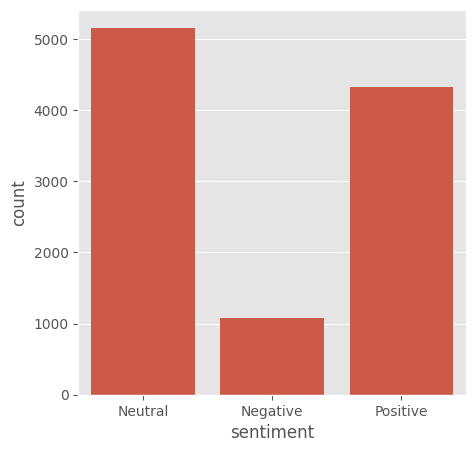

In [ ]:
fig = plt.figure(figsize=(5,5))
sns.countplot(x='sentiment', data = df)

**Data Visualization**

Text(0.5, 1.0, 'Distribution of sentiments')

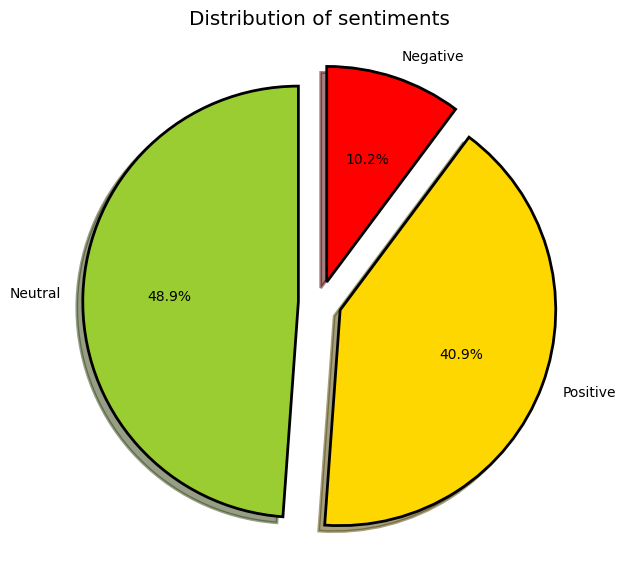

In [ ]:
fig = plt.figure(figsize=(7,7))
colors = ("yellowgreen", "gold", "red")
wp = {'linewidth':2, 'edgecolor':"black"}
tags = df['sentiment'].value_counts()
explode = (0.1,0.1,0.1)
tags.plot(kind='pie', autopct='%1.1f%%', shadow=True, colors = colors,
         startangle=90, wedgeprops = wp, explode = explode, label='')
plt.title('Distribution of sentiments')

In [ ]:
pos_tweets = df[df.sentiment == 'Positive']
pos_tweets = pos_tweets.sort_values(['polarity'], ascending= False)
pos_tweets.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,...,follower_friend_ratio,total_engagement,source_category_other,source_category_web,lexical_diversity,special_char_count,polarity,sentiment,source_category_other,source_category_web
9317,1.410393,Lamon Brown Grier,"Jonesboro, GA",Unknown,2018-03-06 06:46:55,-0.113587,-0.387896,-0.308854,False,2021-07-23 17:25:29,...,-0.133786,-0.147600,False,True,1.0,0,1.0,Positive,False,True
2340,-0.792089,Ruth M,"Northern Ireland, United Kingdom",Married @jen_cossy 👭🏻| Mama to our baby boy 👩‍...,2011-04-25 15:16:53,-0.113409,-0.132033,-0.244289,False,2021-01-05 14:38:38,...,-0.096368,-0.126259,False,False,1.0,0,1.0,Positive,False,False
6295,-0.218414,Alexander Seale,London,"Journaliste indépendant, TV & Radio à Londres ...",2011-04-09 10:46:35,-0.103711,1.395874,0.366976,False,2021-02-26 11:21:40,...,-0.035956,0.316703,False,False,1.0,0,1.0,Positive,False,False
5041,-0.484386,TheMerchJet,"Camden Town, London",🇬🇧🇺🇸🇦🇺🇨🇦🇮🇪🏳️‍🌈🇫🇷🇪🇺🇩🇪🇮🇱🏴󠁧󠁢󠁳󠁣󠁴󠁿🇸🇪🇨🇭🇳🇱🇳🇴Cool stuf...,2017-10-14 12:47:05,-0.113415,-0.026635,-0.310634,False,2021-02-02 10:16:29,...,-0.086655,-0.099535,False,False,1.0,0,1.0,Positive,False,False
1055,-0.970620,Andrew Mseri CEO,Arusha,#Tourism and CEO at KITASA do organize tours i...,2013-06-08 09:04:15,-0.112434,0.075855,-0.225672,False,2020-12-20 11:16:49,...,-0.078397,-0.126259,True,False,1.0,0,1.0,Positive,True,False


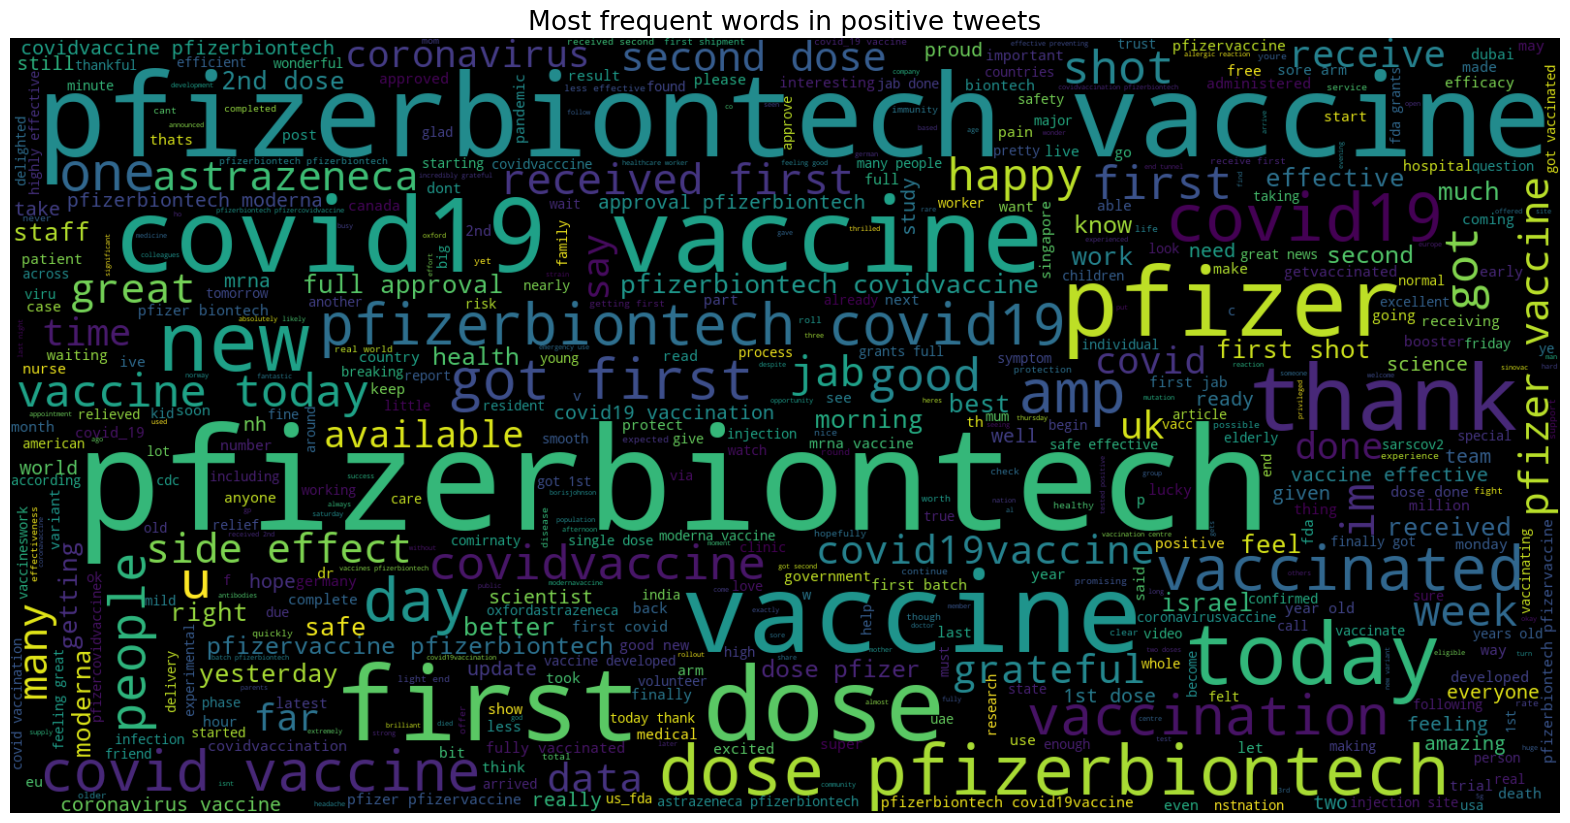

In [ ]:
text = ' '.join([word for word in pos_tweets['text']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Most frequent words in positive tweets', fontsize=19)
plt.show()

In [ ]:
neg_tweets = df[df.sentiment == 'Negative']
neg_tweets = neg_tweets.sort_values(['polarity'], ascending= False)
neg_tweets.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,...,follower_friend_ratio,total_engagement,source_category_other,source_category_web,lexical_diversity,special_char_count,polarity,sentiment,source_category_other,source_category_web
2912,-0.755953,Ceallaigh Zed,"Chicago-adjacent, IL",We are made of star stuff. She/Her.,2008-11-18 16:03:54,-0.113187,-0.094599,-0.129888,False,2021-01-08 21:02:58,...,-0.092497,-0.136929,True,False,1.000000,0,-0.003333,Negative,True,False
7256,0.058460,Uk vaccine data,Unknown,Bio student aiming to provide info about UK 🇬🇧...,2021-02-19 15:33:15,-0.113573,-0.418425,-0.310880,False,2021-03-23 12:06:04,...,-0.140362,-0.115589,False,False,0.923077,0,-0.003409,Negative,False,False
2073,-0.837267,Acidtate,"Worcester, UK",https://t.co/FdUU6yGFK3 https://t.co/bTdtNULvRT,2014-03-23 15:26:04,-0.113325,-0.294128,-0.178394,False,2021-01-01 12:37:12,...,-0.116795,-0.147600,False,False,1.000000,0,-0.004762,Negative,False,False
7715,0.212478,Elango YK,Hong Kong,நம்முள்ளே ஹீரோ .. நாம் தானே ஹீரோ...,2009-12-31 08:17:42,-0.113086,-0.395164,-0.164666,False,2021-04-06 10:16:40,...,-0.134746,0.103201,False,False,1.000000,0,-0.005556,Negative,False,False
7157,0.053251,Emran,London United Kingdom,#IK #PTI,2010-07-28 23:44:06,-0.098557,-0.152022,0.472191,False,2021-03-23 00:48:00,...,-0.086781,-0.136929,False,False,1.000000,1,-0.006250,Negative,False,False


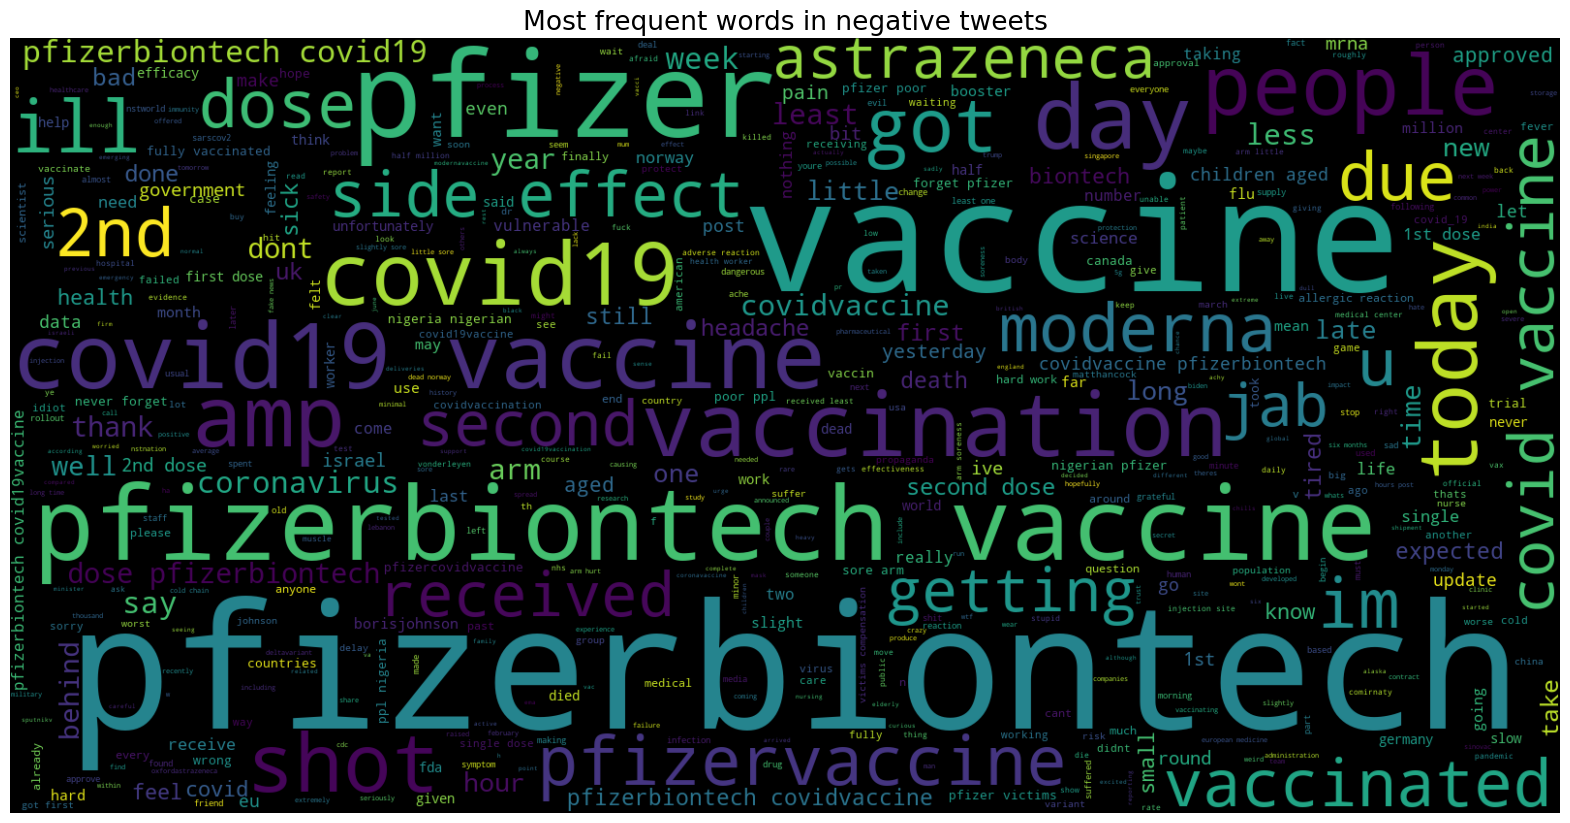

In [ ]:
text = ' '.join([word for word in neg_tweets['text']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Most frequent words in negative tweets', fontsize=19)
plt.show()

In [ ]:
neutral_tweets = df[df.sentiment == 'Neutral']
neutral_tweets = neutral_tweets.sort_values(['polarity'], ascending= False)
neutral_tweets.head()

,id,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,...,follower_friend_ratio,total_engagement,source_category_other,source_category_web,lexical_diversity,special_char_count,polarity,sentiment,source_category_other,source_category_web
0,-0.973002,Rachel Roh,"La Crescenta-Montrose, CA",Aggregator of Asian American news; scanning di...,2009-04-08 17:52:46,-0.112228,0.193610,-0.244453,False,2020-12-20 06:06:44,...,-0.071161,-0.147600,True,False,1.000000,0,0.0,Neutral,True,False
7347,0.092286,Stephanie Willing,Astoria,MG/YA/PB writer; Rep'd by @AllieLevick at Writ...,2013-04-03 01:57:18,-0.111411,0.021703,0.427470,False,2021-03-26 13:29:41,...,-0.081547,-0.019556,False,False,1.000000,0,0.0,Neutral,False,False
7458,0.149420,Ioana Giboi,Unknown,Sharing my REAL childhood stories: Past Tense ...,2021-03-04 13:31:52,-0.112961,-0.291584,-0.299505,False,2021-03-31 17:27:37,...,-0.116061,-0.147600,False,True,0.909091,0,0.0,Neutral,False,True
7454,0.149554,Alexander Black,Berkeley,CTO / Creative / Film,2008-06-18 21:52:42,-0.112877,-0.307939,-0.306563,False,2021-03-31 17:45:05,...,-0.118546,-0.147600,False,True,1.000000,0,0.0,Neutral,False,True
7453,0.149568,Daphne Caine,Isle of Man,MHK for Garff in Isle of Man since 2016. Polit...,2010-06-29 09:01:57,-0.108126,0.147453,0.000348,False,2021-03-31 17:46:51,...,-0.071378,-0.147600,False,False,1.000000,3,0.0,Neutral,False,False


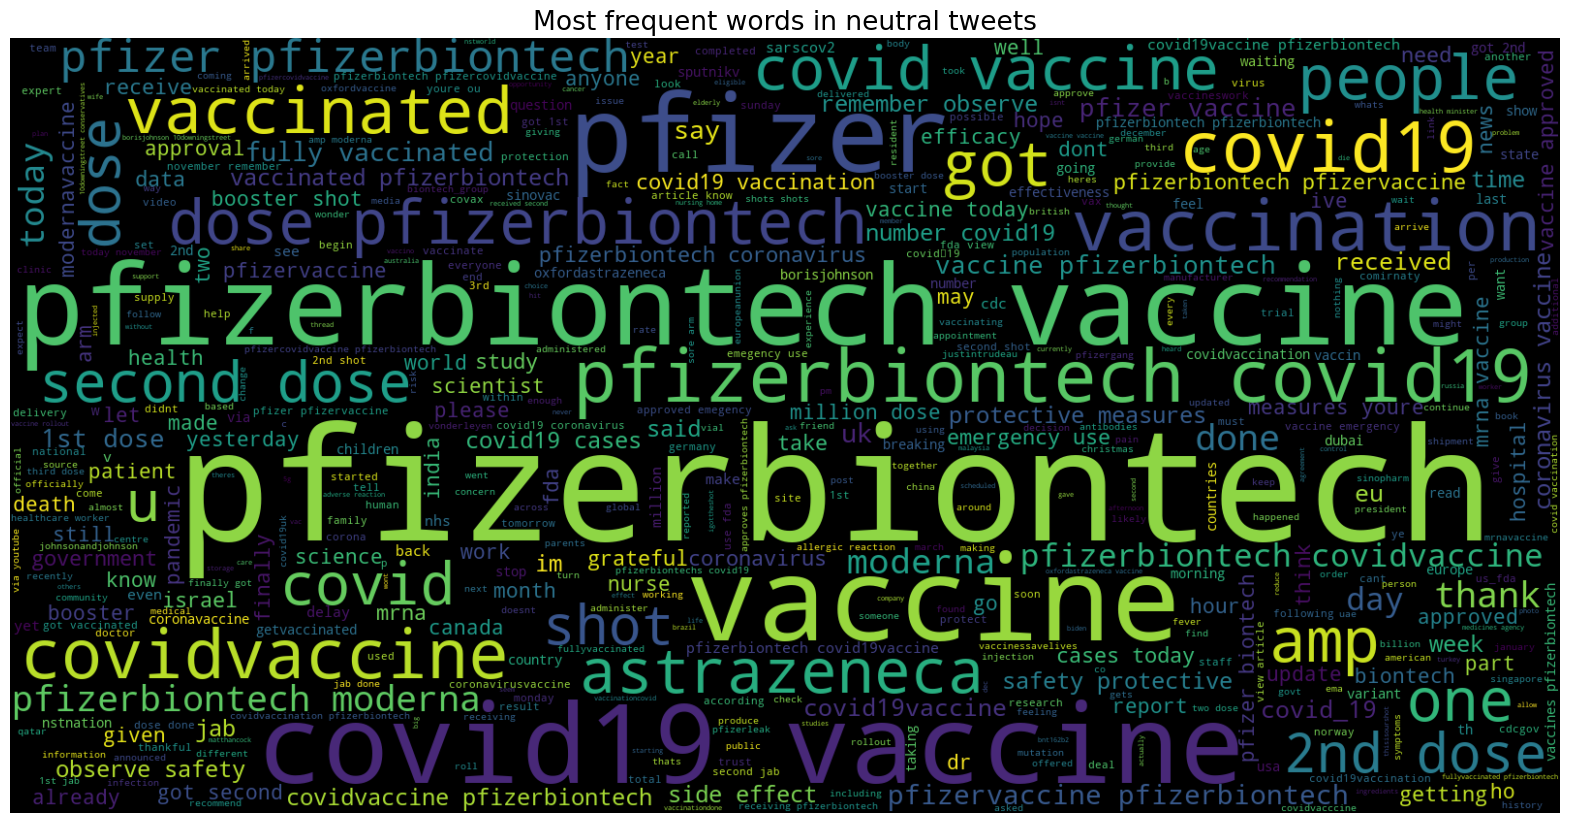

In [ ]:
text = ' '.join([word for word in neutral_tweets['text']])
plt.figure(figsize=(20,15), facecolor='None')
wordcloud = WordCloud(max_words=500, width=1600, height=800).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Most frequent words in neutral tweets', fontsize=19)
plt.show()

In [ ]:
vect = CountVectorizer(ngram_range=(1,2)).fit(df['text'])

In [ ]:
feature_names = vect.get_feature_names_out()
print("Number of features: {}\n".format(len(feature_names)))
print("First 20 features:\n {}".format(feature_names[:20]))

Number of features: 78583

First 20 features:
 ['000' '000 doses' '000 initial' '000 people' '000 vaccines' '0000001'
 '0000001 covid19' '0011' '0011 abt' '004' '004 covid' '004 israelis' '01'
 '01 getting' '01 june' '01 november' '01aug2021' '01aug2021 doublevaxxed'
 '02' '02 175']


**Extracting The Important Features**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying the original DataFrame
df_processed = df.copy()

# Encode categorical features (if any)
label_encoders = {}  # To store encoders for inverse transformation later
for col in df_processed.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le  # Save encoder for decoding later

# Keep only numeric columns
X = df_processed.select_dtypes(include=["number"]).drop(columns=["sentiment"], errors="ignore")  # Replace 'target' with actual label column
y = df_processed["sentiment"]

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)  

RandomForestClassifier(random_state=42)

In [ ]:
feature_importances = rf_model.feature_importances_
feature_names = X.columns

sorted_idx = np.argsort(feature_importances)[::-1]
important_features = [(feature_names[i], feature_importances[i]) for i in sorted_idx]

print("Top 10 Most Important Features:")
for feature, importance in important_features[:10]:
    print(f"{feature}: {importance:.4f}")

Top 10 Most Important Features:
polarity: 0.8949
text: 0.0116
id: 0.0090
hashtags: 0.0083
user_followers: 0.0078
user_favourites: 0.0076
follower_friend_ratio: 0.0076
user_name: 0.0072
user_description: 0.0070
user_created: 0.0069


**Model Training**

In [ ]:
important_features = [
    "polarity", "text", "id", "user_name", "follower_friend_ratio",
    "hashtags", "user_followers", "user_favourites", "user_created", "user_description"
]

X_selected = df_processed[important_features]  
y = df_processed["sentiment"]  

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Size of x_train:", (x_train.shape))
print("Size of y_train:", (y_train.shape))
print("Size of x_test:", (x_test.shape))
print("Size of y_test:", (y_test.shape))

Size of x_train: (8434, 19)
Size of y_train: (8434,)
Size of x_test: (2109, 19)
Size of y_test: (2109,)


In [ ]:
import numpy as np

print("Missing values in x_train:", np.isnan(x_train).sum())  
print("Missing values in y_train:", np.isnan(y_train).sum())

Missing values in x_train: id                       0
user_name                0
user_location            0
user_description         0
user_created             0
user_followers           0
user_friends             0
user_favourites          0
text                     0
hashtags                 0
source                   0
retweets                 0
favorites                0
is_retweet               0
follower_friend_ratio    0
total_engagement         0
lexical_diversity        0
special_char_count       0
polarity                 0
dtype: int64
Missing values in y_train: 0


In [ ]:
import warnings
warnings.filterwarnings('ignore')

Best Hyperparameters: {'solver': 'newton-cg', 'C': 10}
Softmax Regression Accuracy: 0.9734

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.84      0.91       226
           1       0.95      1.00      0.97      1021
           2       1.00      0.98      0.99       862

    accuracy                           0.97      2109
   macro avg       0.98      0.94      0.96      2109
weighted avg       0.97      0.97      0.97      2109



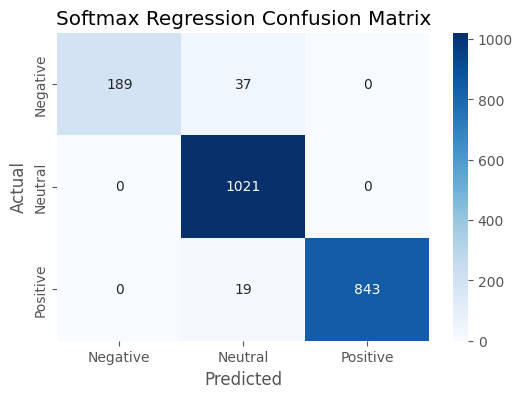

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["newton-cg", "lbfgs", "saga"]
}

softmax = LogisticRegression(multi_class="multinomial", max_iter=500)

random_search = RandomizedSearchCV(softmax, param_grid, cv=5, n_iter=10, scoring="accuracy", random_state=42)
random_search.fit(x_train, y_train)

best_softmax_model = random_search.best_estimator_

softmax_pred = best_softmax_model.predict(x_test)

print("Best Hyperparameters:", random_search.best_params_)

softmax_acc = accuracy_score(y_test, softmax_pred)
print(f"Softmax Regression Accuracy: {softmax_acc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, softmax_pred))

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, softmax_pred, "Softmax Regression Confusion Matrix")

Best Hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}
Random Forest Accuracy: 0.9995

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       226
           1       1.00      1.00      1.00      1021
           2       1.00      1.00      1.00       862

    accuracy                           1.00      2109
   macro avg       1.00      1.00      1.00      2109
weighted avg       1.00      1.00      1.00      2109



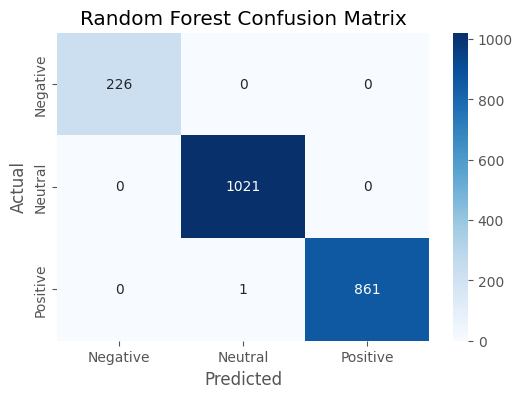

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

param_grid = {
    "n_estimators": [50, 100, 200, 500], 
    "max_depth": [None, 10, 20, 30],  
    "min_samples_split": [2, 5, 10],  
    "min_samples_leaf": [1, 2, 4],  
    "bootstrap": [True, False],  
}

rf_model = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    cv=5,
    n_iter=10,
    scoring="accuracy",
    random_state=42
)

random_search.fit(x_train, y_train)

best_rf_model = random_search.best_estimator_

rf_pred = best_rf_model.predict(x_test)

print("Best Hyperparameters:", random_search.best_params_)

rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, rf_pred))

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, rf_pred, "Random Forest Confusion Matrix")


Best Hyperparameters: {'var_smoothing': 1e-09}
Naive Bayes Accuracy: 0.9004

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.78      0.84       226
           1       0.84      0.98      0.91      1021
           2       0.99      0.84      0.91       862

    accuracy                           0.90      2109
   macro avg       0.92      0.87      0.89      2109
weighted avg       0.91      0.90      0.90      2109



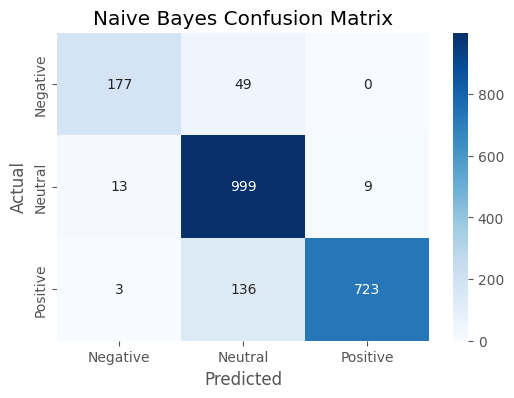

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

param_grid = {
    "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

nb_model = GaussianNB()

random_search = RandomizedSearchCV(
    estimator=nb_model,
    param_distributions=param_grid,
    cv=5,
    n_iter=10,
    scoring="accuracy",
    random_state=42
)

random_search.fit(x_train, y_train)

best_nb_model = random_search.best_estimator_

nb_pred = best_nb_model.predict(x_test)

print("Best Hyperparameters:", random_search.best_params_)

nb_acc = accuracy_score(y_test, nb_pred)
print(f"Naive Bayes Accuracy: {nb_acc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, nb_pred))

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, nb_pred, "Naive Bayes Confusion Matrix")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters for Extra Trees: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'gini', 'bootstrap': False}
Extra Trees Accuracy: 0.9559

Classification Report for Extra Trees:
               precision    recall  f1-score   support

           0       1.00      0.74      0.85       226
           1       0.92      1.00      0.96      1021
           2       1.00      0.96      0.98       862

    accuracy                           0.96      2109
   macro avg       0.97      0.90      0.93      2109
weighted avg       0.96      0.96      0.95      2109



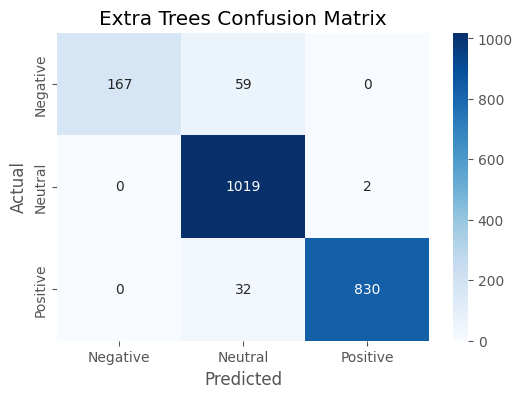

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

param_grid = {
    "n_estimators": [50, 100, 200, 500],  
    "max_depth": [None, 10, 20, 30], 
    "min_samples_split": [2, 5, 10], 
    "min_samples_leaf": [1, 2, 4],  
    "max_features": ['auto', 'sqrt', 'log2'],  
    "bootstrap": [True, False],  
    "criterion": ['gini', 'entropy']  
}

et_model = ExtraTreesClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=et_model,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring="accuracy",
    random_state=42
)

random_search.fit(x_train, y_train)

best_et_model = random_search.best_estimator_

et_pred = best_et_model.predict(x_test)

print("Best Hyperparameters for Extra Trees:", random_search.best_params_)

et_acc = accuracy_score(y_test, et_pred)
print(f"Extra Trees Accuracy: {et_acc:.4f}")

print("\nClassification Report for Extra Trees:\n", classification_report(y_test, et_pred))

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, et_pred, "Extra Trees Confusion Matrix")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters for Logistic Regression: {'solver': 'newton-cg', 'penalty': 'l2', 'multi_class': 'multinomial', 'max_iter': 300, 'class_weight': None, 'C': 100}
Logistic Regression Accuracy: 0.9910

Classification Report for Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98       226
           1       0.98      1.00      0.99      1021
           2       1.00      0.99      0.99       862

    accuracy                           0.99      2109
   macro avg       0.99      0.98      0.99      2109
weighted avg       0.99      0.99      0.99      2109



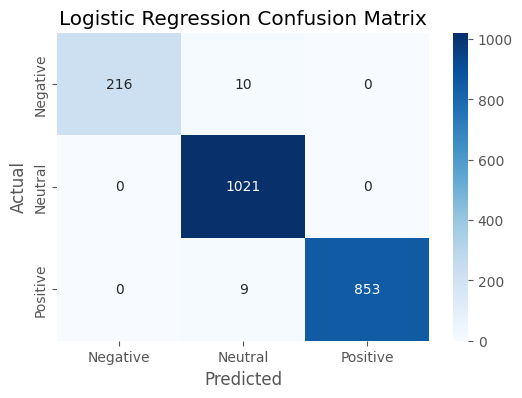

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],  
    'C': [0.001, 0.01, 0.1, 1, 10, 100], 
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],  
    'max_iter': [100, 200, 300],  
    'multi_class': ['ovr', 'multinomial'],  
    'class_weight': [None, 'balanced'] 
}

logreg_model = LogisticRegression(random_state=42)

random_search = RandomizedSearchCV(
    estimator=logreg_model,
    param_distributions=param_grid,
    n_iter=10,  
    cv=5,  
    verbose=2, 
    n_jobs=-1,  
    scoring="accuracy",  
    random_state=42
)

random_search.fit(x_train, y_train)

best_logreg_model = random_search.best_estimator_

logreg_pred = best_logreg_model.predict(x_test)

print("Best Hyperparameters for Logistic Regression:", random_search.best_params_)

logreg_acc = accuracy_score(y_test, logreg_pred)
print(f"Logistic Regression Accuracy: {logreg_acc:.4f}")

print("\nClassification Report for Logistic Regression:\n", classification_report(y_test, logreg_pred))

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, logreg_pred, "Logistic Regression Confusion Matrix")


Voting Classifier Accuracy: 0.9957

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       226
           1       0.99      1.00      1.00      1021
           2       1.00      0.99      0.99       862

    accuracy                           1.00      2109
   macro avg       1.00      1.00      1.00      2109
weighted avg       1.00      1.00      1.00      2109



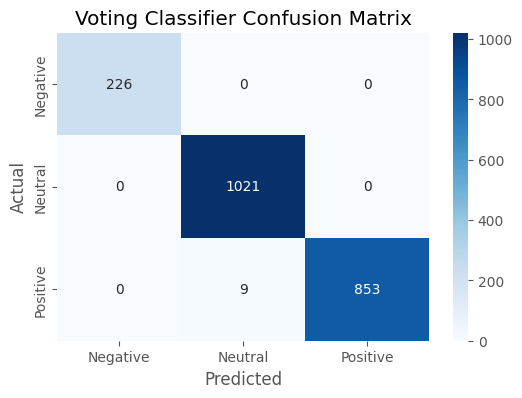

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

logistic_model = best_logreg_model  

random_forest = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

random_forest.fit(x_train, y_train)

voting_clf = VotingClassifier(estimators=[
    ('logistic', logistic_model),
    ('random_forest', random_forest)
], voting='hard') 

voting_clf.fit(x_train, y_train)

voting_pred = voting_clf.predict(x_test)

voting_acc = accuracy_score(y_test, voting_pred)
print(f"Voting Classifier Accuracy: {voting_acc:.4f}")

print("\nClassification Report:\n", classification_report(y_test, voting_pred))

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()
    
plot_confusion_matrix(y_test, voting_pred, "Voting Classifier Confusion Matrix")

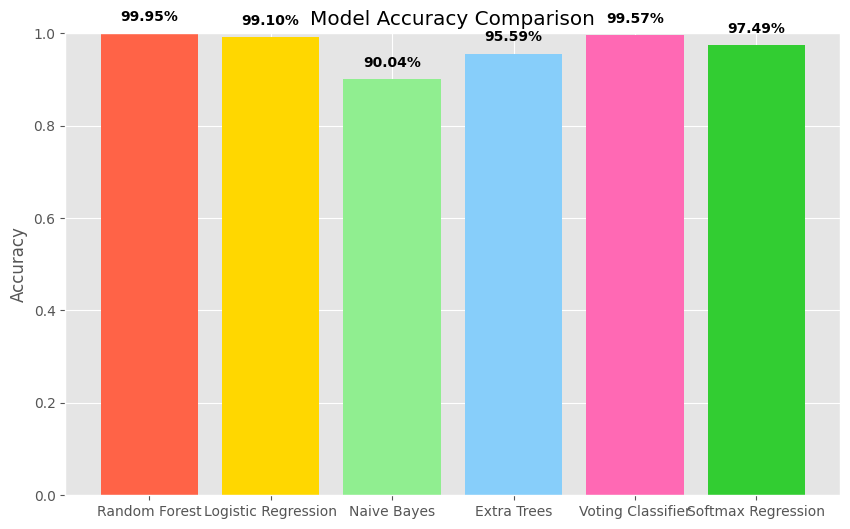

In [ ]:
models = ['Random Forest', 'Logistic Regression', 'Naive Bayes', 'Extra Trees', 'Voting Classifier', 'Softmax Regression']
accuracies = [rf_acc, logreg_acc, nb_acc, et_acc, voting_acc, softmax_acc] 

colors = ['#FF6347', '#FFD700', '#90EE90', '#87CEFA', '#FF69B4', '#32CD32']  

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1) 

for index, value in enumerate(accuracies):
    plt.text(index, value + 0.02, f'{value*100:.2f}%', ha='center', va='bottom', color='black', fontweight='bold')

plt.show()


In [ ]:
import numpy as np

sample_data = np.array([[1, 1, 0, 0, 3, 0, 0, 0, 1, 1, 0, 0, 0, 2, 1, 0, 1, 1, 0]]) 

if sample_data.shape[1] != x_train.shape[1]:
    raise ValueError(f"Sample data has {sample_data.shape[1]} features, but the model expects {x_train.shape[1]}.")

prediction = best_rf_model.predict(sample_data)

print(f"Predicted Class: {prediction[0]}")

Predicted Class: 1


In [ ]:
print(f"Random Forest was trained with {x_train.shape[1]} features.")

Random Forest was trained with 19 features.
